# Revenue Maximisation
---

This notebook explores various aspects of a company's sales data to identify opportunities for increasing revenue. It covers everything from preparing the raw data to making strategic recommendations.

## Table of Contents

<details>
<summary><b>1. Data Cleaning & Preprocessing</b></summary>

- [1.1 Load Packages & Raw Data](#load-raw-data)
- [1.2 Data Audit](#data-audit)
- [1.3 Descriptive Statistics](#descriptive-statistics)
- [1.4 Rename Columns](#rename-columns)
- [1.5 Extract Date Features](#extract-date-features)
- [1.6 Duplicate Analysis](#duplicate-analysis)
- [1.7 Aggregate Duplicates](#aggregate-duplicates)
- [1.8 Remove Invalid Rows](#remove-invalid-rows)
- [1.9 Revenue Bands](#added-revenue-bands)

</details>

<details>
<summary><b>2. Exploratory Data Analysis</b></summary>

- [2.1 Regional OLS](#regional-ols)
- [2.2 Geographic Gap Analysis](#geo-gap)
- [2.3 Revenue Trend by Fiscal Year](#revenue-trend)
- [2.4 YoY Seasonality](#yoy-seasonality)

</details>

<details>
<summary><b>3. Advanced Analysis</b></summary>

- [3.1 BCG Matrix — Division Performance](#bcg-matrix)
- [3.2 Price Elasticity by Product Class](#price-elasticity)
- [3.3 Customer Pareto](#customer-pareto)
- [3.4 Top 10 Customers](#top10-customers)
- [3.5 Customer Churn (FY2023 → FY2025)](#customer-churn)
- [3.6 RFM Segmentation](#rfm)
- [3.7 Cohort Retention](#cohort)
- [3.8 AOV Trend by Product Class](#aov-trend)
- [3.9 Product Mix Evolution](#product-mix)
- [3.10 Cross-sell Gap](#cross-sell-gap)
- [3.11 SKU Pareto](#sku-pareto)
- [3.12 Top 10 SKUs](#top10-skus)

</details>

<details>
<summary><b>4. Three-year Revenue Forecast based on current trend</b></summary>

- [4.1 FY2027 & FY2028 Forecast](#prophet-forecast)

</details>

<details>
<summary><b>5 Strategic Recommendations</b></summary>

- [5.1  Strategic Recommendations](#recomendations)

</details>

<details>
<summary><b>6 Revenue Uplift Post Strategy Implementation</b></summary>

- [6.1  Results](#uplift)

</details>

*Click on any section to expand/collapse*

# 1 Data Cleaning and Preprocessing

This section focuses on getting our raw sales data ready for analysis. We'll check for errors, fix inconsistencies, and transform the data into a usable format. Clean data is crucial for accurate insights!

## <a id='load-raw-data'></a>1.1 Load Packages & Raw Data

Here, we bring in all the necessary Python tools (like pandas for data handling and matplotlib for plotting) and load our main sales dataset from a file into the notebook. This is the starting point for all our analysis.

In [266]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')


In [ ]:
# Load raw data from parquet file
df_raw = pd.read_parquet("final_student_dataset.parquet")
# Display shape and column names
df_raw.shape, list(df_raw.columns)

((2421385, 16),
 ['order number',
  'product_class',
  'cdm duns name',
  'cdm parent duns name',
  'amount p$',
  'cdm end market',
  'division',
  'order create date',
  'fiscal year',
  'hfm region',
  'hfm region group',
  'sku name',
  'sku number',
  'quantity',
  'ship to number',
  'ship to name'])

## <a id='data-audit'></a>1.2 Data Audit

A 'data audit' is like a health check for our data. We'll examine things like missing values (empty spots in our data) and duplicate entries to understand the data's quality and identify areas that need fixing.

In [268]:
# Calculate null counts and percentages for each column
null_df = pd.DataFrame({
    "null_count": df_raw.isnull().sum(),
    "null_pct_%": (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
null_df

# Check for fully duplicate rows and duplicate order+sku pairs
print(f"Fully duplicate rows: {df_raw.duplicated().sum()}")
print(f"Duplicate (order + sku) pairs: {df_raw.duplicated(subset=['order number','sku number']).sum()}")

Fully duplicate rows: 242223
Duplicate (order + sku) pairs: 414351


## <a id='descriptive-statistics'></a>1.3 Descriptive Statistics

Descriptive statistics give us a quick summary of the data, especially for numbers like 'amount p$' (sales amount) and 'quantity'. This helps us understand the typical values, how spread out they are, and if there are any extreme numbers that might be errors.

In [269]:
# Convert 'amount p$' and 'quantity' to numeric, coercing errors
df_raw["amount p$"] = pd.to_numeric(df_raw["amount p$"], errors="coerce")
df_raw["quantity"] = pd.to_numeric(df_raw["quantity"], errors="coerce")

# Display descriptive statistics for 'amount p$' and 'quantity'
df_raw[["amount p$", "quantity"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)

,amount p$,quantity
count,"2,421,385.00","2,421,385.00"
mean,"3,056.59",20.33
std,"86,246.95","1,040.99"
min,0.00,"-1,000.00"
1%,1.00,1.00
5%,5.00,1.00
25%,62.00,1.00
50%,216.00,1.00
75%,702.00,5.00
95%,"6,342.00",36.00


In [270]:
# Count rows where 'amount p$' is zero
df_raw[df_raw["amount p$"] == 0].shape[0]

22373

In [271]:
# Count rows where 'quantity' is negative
df_raw[df_raw["quantity"] < 0].shape[0]

173

### Categorical Distributions

Categorical data refers to information that can be divided into groups or categories (like 'product_class' or 'hfm region'). Looking at their distributions helps us understand the variety and commonness of different categories within our data.

In [272]:
# List of columns to convert to 'category' dtype
category_cols = [
    'product_class', 'cdm duns name', 'cdm parent duns name',
    'cdm end market', 'division', 'hfm region', 'hfm region group',
    'sku name'
]
# Apply conversion to category type
for col in category_cols:
    df_raw[col] = df_raw[col].astype('category')

# Display data types after conversion
df_raw.dtypes

order number                    object
product_class                 category
cdm duns name                 category
cdm parent duns name          category
amount p$                      float64
cdm end market                category
division                      category
order create date       datetime64[us]
fiscal year                      int32
hfm region                    category
hfm region group              category
sku name                      category
sku number                      object
quantity                       float64
ship to number                  object
ship to name                    object
dtype: object

In [273]:
# Count unique values for all columns
df_raw.nunique()

order number            844786
product_class                2
cdm duns name            30906
cdm parent duns name     22860
amount p$                43658
cdm end market              12
division                    24
order create date         1210
fiscal year                  4
hfm region                  16
hfm region group             8
sku name                146651
sku number              155758
quantity                  3078
ship to number           61108
ship to name             41647
dtype: int64

### Date Range Check

It's important to confirm the time period covered by our sales data. Here, we check the earliest and latest order dates and the fiscal years included. This ensures we're analyzing the correct timeframe and understanding how the company's financial years are defined (e.g., starting in October).

In [274]:
# Print the min and max dates in 'order create date'
print(f"Date range: {df_raw['order create date'].min().date()} to {df_raw['order create date'].max().date()}")
# Count occurrences of each 'fiscal year'
df_raw["fiscal year"].value_counts()

Date range: 2023-01-01 to 2026-04-24


fiscal year
2023    767364
2024    746821
2025    711230
2026    195970
Name: count, dtype: int64

## <a id='rename-columns'></a>1.4 Rename Columns

To make our data easier to work with and understand, we'll rename some of the column headers. For example, replacing spaces with underscores makes them easier to use in code, and clarifying 'p$' to 'usd' makes the currency explicit.

In [275]:
# Create a copy of the raw DataFrame
df = df_raw.copy()
# Rename columns: replace spaces with underscores and 'p$' with 'usd'
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('p$', 'usd')
# Display the new column names
df.columns

Index(['order_number', 'product_class', 'cdm_duns_name',
       'cdm_parent_duns_name', 'amount_usd', 'cdm_end_market', 'division',
       'order_create_date', 'fiscal_year', 'hfm_region', 'hfm_region_group',
       'sku_name', 'sku_number', 'quantity', 'ship_to_number', 'ship_to_name'],
      dtype='object')

In [276]:
# Display value counts for 'cdm_duns_name'
df['cdm_duns_name'].value_counts()

cdm_duns_name
Garcia, White and Thompson       47508
Simpson-Solis                    32143
Salazar, Smith and Spencer       22469
Weber, Delgado and Brown         19986
Edwards-Watkins                  19307
                                 ...  
Bell-Washington                      1
Rojas Group                          1
Rogers-Washington                    1
Kline-Thompson                       1
Johnston, Williams and Nguyen        1
Name: count, Length: 30906, dtype: int64

## <a id='extract-date-features'></a>1.5 Extract Date Features

In [277]:
# Extract year, month, and quarter from 'order_create_date'
df["year"] = df["order_create_date"].dt.year
df["month"] = df["order_create_date"].dt.month
df["quarter"] = df["order_create_date"].dt.quarter

# Derive fiscal year based on month (October onwards belongs to next year)
df["fiscal_year_derived"] = df["year"] + (df["month"] >= 10).astype(int)
# Identify discrepancies between original and derived fiscal year
incorrect_fy = (df["fiscal_year"] - df["fiscal_year_derived"]) > 1
incorrect_fy.value_counts()

False    2419637
True        1748
Name: count, dtype: int64

### Correcting the wrong fiscal year

Sometimes, the original data might have an incorrect fiscal year. This step corrects the fiscal year based on the month of the order. If an order date falls in October or later, it's considered part of the *next* fiscal year, aligning with the company's fiscal calendar.

In [278]:
# Correct the derived fiscal year logic
df["fiscal_year_derived"] = (np.where(df["month"] >= 10, df["year"] + 1, df["year"])).astype(int)
# Display value counts of the corrected derived fiscal year
df["fiscal_year_derived"].value_counts().sort_index()

fiscal_year_derived
2023    621666
2024    756373
2025    705085
2026    338261
Name: count, dtype: int64

## <a id='duplicate-analysis'></a>1.6 Duplicate Analysis

We need to check for duplicate entries in our data. Duplicates can skew our analysis, making it seem like we have more sales or orders than we actually do. This step helps us identify and understand these repetitions.

In [279]:
# Create a mask for duplicate 'order_number' and 'sku_number' combinations
dup_mask = df.duplicated(subset=["order_number", "sku_number"], keep=False)
# Calculate size of each group of duplicates
group_sizes = df.groupby(['order_number', 'sku_number']).size()
# Print summary of duplicate rows
print(f"Total rows: {len(df):,}")
print(f"Unique order+SKU combinations: {len(group_sizes):,}")
print(f"Rows with duplicates: {dup_mask.sum():,}")
print(f"\nGroup size distribution:")
group_sizes.value_counts()

Total rows: 2,421,385
Unique order+SKU combinations: 2,007,034
Rows with duplicates: 583,251

Group size distribution:


1      1838134
2       118542
3        21276
4         9684
5         3714
        ...   
367          1
132          1
198          1
166          1
389          1
Name: count, Length: 119, dtype: int64

## <a id='aggregate-duplicates'></a>1.7 Aggregate Duplicates

After finding duplicate entries (e.g., the same order number and SKU appearing multiple times), we need to combine them. Instead of simply deleting, we'll sum up the quantities and amounts for these duplicates to ensure accurate totals, while keeping important first-seen details like product names or dates.

In [280]:
# Aggregate duplicate rows by 'order_number' and 'sku_number'
df = df.groupby(
    ["order_number", "sku_number"],
    as_index=False
).agg({
    "amount_usd": "sum",
    "quantity": "sum",
    "sku_name": "first",
    "division": "first",
    "product_class": "first",
    "cdm_end_market": "first",
    "hfm_region": "first",
    "hfm_region_group": "first",
    "ship_to_name": "first",
    "ship_to_number": "first",
    "cdm_duns_name": "first",
    "cdm_parent_duns_name": "first",
    "fiscal_year": "first",
    "fiscal_year_derived": "first",
    "order_create_date": "min"
})

# Re-derive date parts and enforce correct dtypes after aggregation
df["year"]  = df["order_create_date"].dt.year.astype("Int32")
df["month"] = df["order_create_date"].dt.month.astype("Int32")
df["quarter"] = df["order_create_date"].dt.quarter.astype("Int32")
df["fiscal_year_derived"] = df["fiscal_year_derived"].astype("Int32")
df["month_period"] = df["order_create_date"].dt.to_period("M")

# Print the number of rows after aggregation
print(f"Rows after aggregation: {len(df):,}")

Rows after aggregation: 2,007,034


In [281]:
# Check for any remaining duplicate rows after aggregation
df.duplicated().sum()

np.int64(0)

## <a id='remove-invalid-rows'></a>1.8 Remove Invalid Rows

This step is about cleaning out data that doesn't make sense or could be errors. We'll specifically look for and remove sales entries where the 'amount_usd' (total revenue) is zero, as these don't represent actual revenue-generating transactions.

In [282]:
# Remove rows where 'amount_usd' is not greater than 0
df = df[df["amount_usd"] > 0].reset_index(drop=True)
# Print the number of rows after removal
print(f"Rows after removal: {len(df):,}")

Rows after removal: 1,989,489


### Remove Invalid Quantity Rows

Just like removing zero-revenue orders, we also need to address cases where the quantity of items sold is incorrect or invalid. For instance, negative quantities are usually data entry errors and don't represent real sales, so we remove them to maintain data integrity.

In [283]:
# Remove rows where 'quantity' is less than 1 (invalid quantity)
df = df[df["quantity"] >= 1].reset_index(drop=True)
# Print the number of rows after filtering
print(f"Rows after quantity filter (>=1): {len(df):,}")

Rows after quantity filter (>=1): 1,988,535


### Compute Unit Price & Remove Anomalies

Here, we calculate the 'unit_price' for each item by dividing the total sale amount by the quantity. We then look for and remove unusual data points, called 'anomalies' (e.g., items with extremely low unit prices but very high quantities), which could distort our analysis and suggest data errors.

In [284]:
# Compute 'unit_price'
df["unit_price"] = df["amount_usd"] / df["quantity"]
# Identify and remove anomalous rows (very low unit price, very high quantity)
bad_rows = df[(df["unit_price"] < 0.001) & (df["quantity"] > 100000)]
df = df.drop(bad_rows.index).reset_index(drop=True)

print(f"Anomaly rows removed: {len(bad_rows)}")

Anomaly rows removed: 2


### Remove High-Revenue Outliers

'Outliers' are data points that are very different from the rest. In this case, we're removing sales orders with extremely high revenue (e.g., over $50 million) that might be errors or unique events not representative of typical business. These extreme values can skew our overall analysis.

In [285]:
rev_threshold = 50000000
df["high_revenue_flag"] = (df["amount_usd"] > rev_threshold)
display(df[df["high_revenue_flag"] == True][["order_number", "sku_name", 'quantity', "amount_usd"]])

# Remove high-revenue outlier rows
df = df[~df["high_revenue_flag"]].reset_index(drop=True)

,order_number,sku_name,quantity,amount_usd
1235463,753351,Concern Fire Kit,1.00,"112,340,132.00"


In [286]:
# Display the shape of the DataFrame after outlier removal
df.shape

(1988532, 23)

## <a id='added-revenue-bands'></a>1.9 Revenue Bands

To make it easier to analyze sales amounts, we'll group them into different 'revenue bands' or categories (e.g., sales less than $100, sales between $100-$500, etc.). This helps us understand the distribution of sales values and identify common transaction sizes.

In [287]:
# Create revenue bands using pd.cut
df["revenue_band"] = pd.cut(
    df["amount_usd"],
    bins=[0, 100, 500, 2000, 10000, float("inf")],
    labels=["<$100", "$100-500", "$500-2K", "$2K-10K", "$10K+"]
)
# Display value counts of the revenue bands
df["revenue_band"].value_counts().sort_index()

revenue_band
<$100       571594
$100-500    732672
$500-2K     418828
$2K-10K     188751
$10K+        76687
Name: count, dtype: int64

In [288]:
# Display the shape of the DataFrame
df.shape

(1988532, 24)

### Data Reduction Summary

This table provides a summary of how many rows were removed or aggregated at each stage of the data cleaning process. It shows the original number of data entries and how it changed as invalid or duplicate records were handled, resulting in a cleaner, more accurate dataset for analysis.
| Stage | Rows Changed | Total |
|:---|---:|---:|
| Raw | - | 2,421,385 |
| Aggregate duplicates | -414,351 | 2,007,034 |
| Remove zero revenue | -17,545 | 1,989,489 |
| Remove invalid qty | -954 | 1,988,535 |
| Remove anomalies | -2 | 1,988,533 |
| Remove outlier | -1 | 1,988,532 |

In [289]:
# Save the cleaned DataFrame to a parquet file
df.to_parquet("cleaned_dataset.parquet", index=False)

In [290]:
# Display descriptive statistics for the cleaned DataFrame
df.describe()

,amount_usd,quantity,fiscal_year,fiscal_year_derived,order_create_date,year,month,quarter,unit_price
count,"1,988,532.00","1,988,532.00","1,988,532.00","1,988,532.00",1988532,"1,988,532.00","1,988,532.00","1,988,532.00","1,988,532.00"
mean,"3,661.58",23.69,"2,024.15","2,024.33",2024-08-01 01:15:22.099317,"2,024.10",6.32,2.42,"2,388.17"
min,1.00,1.00,"2,023.00","2,023.00",2023-01-01 00:00:00,"2,023.00",1.00,1.00,0.00
25%,83.00,1.00,"2,023.00","2,024.00",2023-10-01 00:00:00,"2,023.00",3.00,1.00,33.00
50%,257.00,2.00,"2,024.00","2,024.00",2024-07-22 00:00:00,"2,024.00",6.00,2.00,106.00
75%,841.00,4.00,"2,025.00","2,025.00",2025-05-27 00:00:00,"2,025.00",9.00,3.00,394.00
max,"10,588,288.00","500,000.00","2,026.00","2,026.00",2026-04-24 00:00:00,"2,026.00",12.00,4.00,"7,720,000.00"
std,"57,270.94",671.36,0.96,1.01,NaN,0.95,3.49,1.13,"49,179.14"


# <a id='eda-plan'></a>2 Exploratory Data Analysis

This section is all about understanding our cleaned data. We'll use various techniques, including visualizations, to find patterns, relationships, and interesting insights that can inform our revenue maximization strategy.

## <a id='regional-ols'></a>2.1 Regional OLS (Order Count → Revenue)

Here, we use a statistical technique called Ordinary Least Squares (OLS) to understand the relationship between the number of orders and total revenue in different geographic regions. We want to see how strongly an increase in orders in a region affects its revenue.

In [291]:
from sklearn.linear_model import LinearRegression

# group revenue and order count by region
region_agg = df.groupby('hfm_region').agg(
    total_rev=('amount_usd', 'sum'),
    order_count=('order_number', 'nunique')
).reset_index()

# log transform for better linear fit
region_agg['log_rev'] = np.log(region_agg['total_rev'])
region_agg['log_orders'] = np.log(region_agg['order_count'])

# fit linear regression
model = LinearRegression()
model.fit(region_agg[['log_orders']], region_agg['log_rev'])
r2 = model.score(region_agg[['log_orders']], region_agg['log_rev'])

print(f'Regional R-squared: {r2:.2f}')
print(f'This means {r2*100:.0f}% of revenue variation is explained by order count')

# also compute instrument multiplier using simple groupby
avg_by_class = df.groupby('product_class')['amount_usd'].mean()
if 'Instruments' in avg_by_class.index and 'Consumables' in avg_by_class.index:
    instrument_multiplier = avg_by_class['Instruments'] / avg_by_class['Consumables']
    print(f'Instrument revenue multiplier: {instrument_multiplier:.2f}x')


Regional R-squared: 0.93
This means 93% of revenue variation is explained by order count
Instrument revenue multiplier: 13.24x


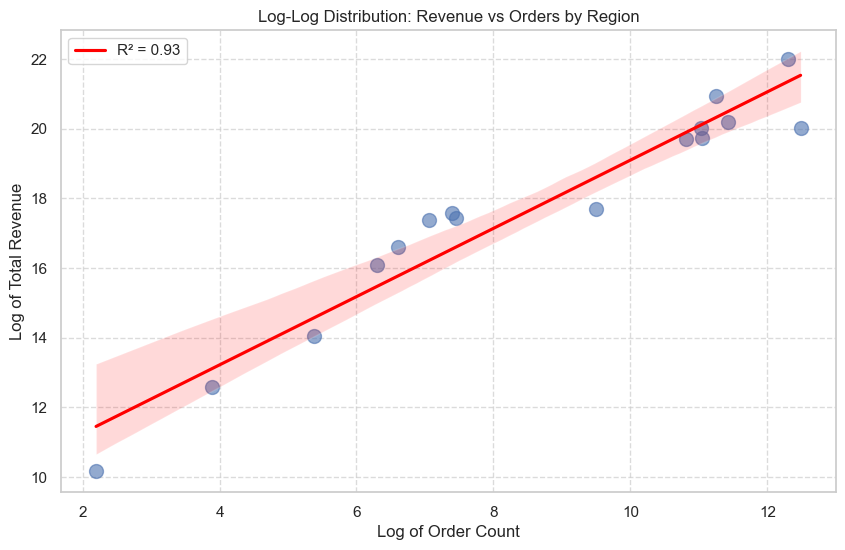

In [292]:
# Create a scatter plot with regression line for log-log distribution of revenue vs orders
plt.figure(figsize=(10, 6))
sns.regplot(x='log_orders', y='log_rev', data=region_agg,
            scatter_kws={'s': 100, 'alpha': 0.6},
            line_kws={'color': 'red', 'label': f'R² = {r2_reg:.2f}'})

plt.title('Log-Log Distribution: Revenue vs Orders by Region')
plt.xlabel('Log of Order Count')
plt.ylabel('Log of Total Revenue')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

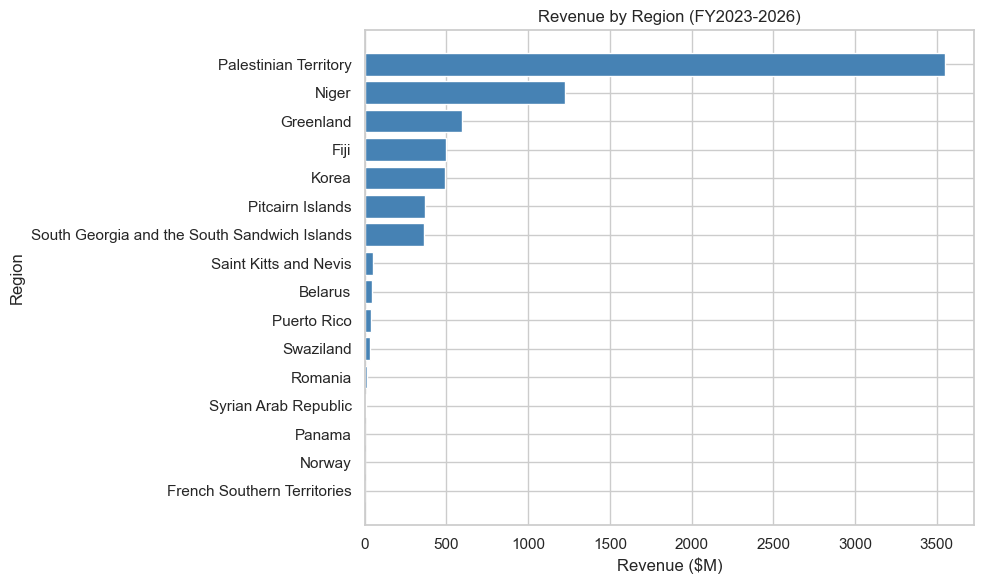

In [293]:
fig, ax = plt.subplots(figsize=(10, 6))
region_agg_sorted = region_agg.sort_values('total_rev', ascending=True)
ax.barh(region_agg_sorted['hfm_region'], region_agg_sorted['total_rev']/1e6, color='steelblue')
ax.set_xlabel('Revenue ($M)')
ax.set_ylabel('Region')
ax.set_title('Revenue by Region (FY2023-2026)')
plt.tight_layout()
plt.show()

**Result:** Order count explains **93%** of regional revenue variation.

This means that 93% of the differences in revenue between regions can be explained simply by the number of orders they receive. The remaining 7% could be due to other factors.

### What were we trying to find?
We wanted to understand **what drives revenue differences across regions**. The simplest idea was: regions with more orders naturally make more money. But *how strong* is that connection — and is it true for all regions?

To figure this out, we used a **Log-Log OLS regression**. This is a statistical method that looks at the relationship between the *logarithm* of revenue and the *logarithm* of the number of orders across all regions. Using the 'log' scale helps us see the overall trend without a few very large regions making the results look misleading.

### What did we find?
-   **R² = 0.93** — This number tells us that the number of orders alone explains 93% of why revenue varies from one region to another.
-   This means that regional revenue is mostly about the *number of sales* (volume), not so much about charging higher prices or selling a different mix of products.
-   **Implication:** If you want to increase a region's revenue, the most effective way is to get more orders, rather than trying to sell more expensive items or change what's being sold within existing orders.

## <a id='geo-gap'></a>2.2 Geographic Gap Analysis

Our previous analysis showed that the number of orders is a major driver of regional revenue. This section takes that a step further: it compares each region to the top-performing one, identifying how much more revenue other regions *could* generate if they performed at the same level. This shows us the potential 'dollar opportunity' in closing these gaps.

In [294]:
# Benchmark: region with highest avg revenue per order
region_perf = df.groupby('hfm_region_group').agg(
    total_revenue=('amount_usd', 'sum'),
    order_count=('order_number', 'nunique'),
    avg_per_order=('amount_usd', 'mean')
).reset_index()

benchmark_row  = region_perf.loc[region_perf['avg_per_order'].idxmax()]
benchmark_name = benchmark_row['hfm_region_group']
benchmark_avg  = benchmark_row['avg_per_order']

region_perf['gap_per_order'] = benchmark_avg - region_perf['avg_per_order']
region_perf['total_gap_usd'] = region_perf['gap_per_order'] * region_perf['order_count']
region_perf = region_perf.sort_values('total_gap_usd', ascending=False)


### Geographic Gap Visualizations

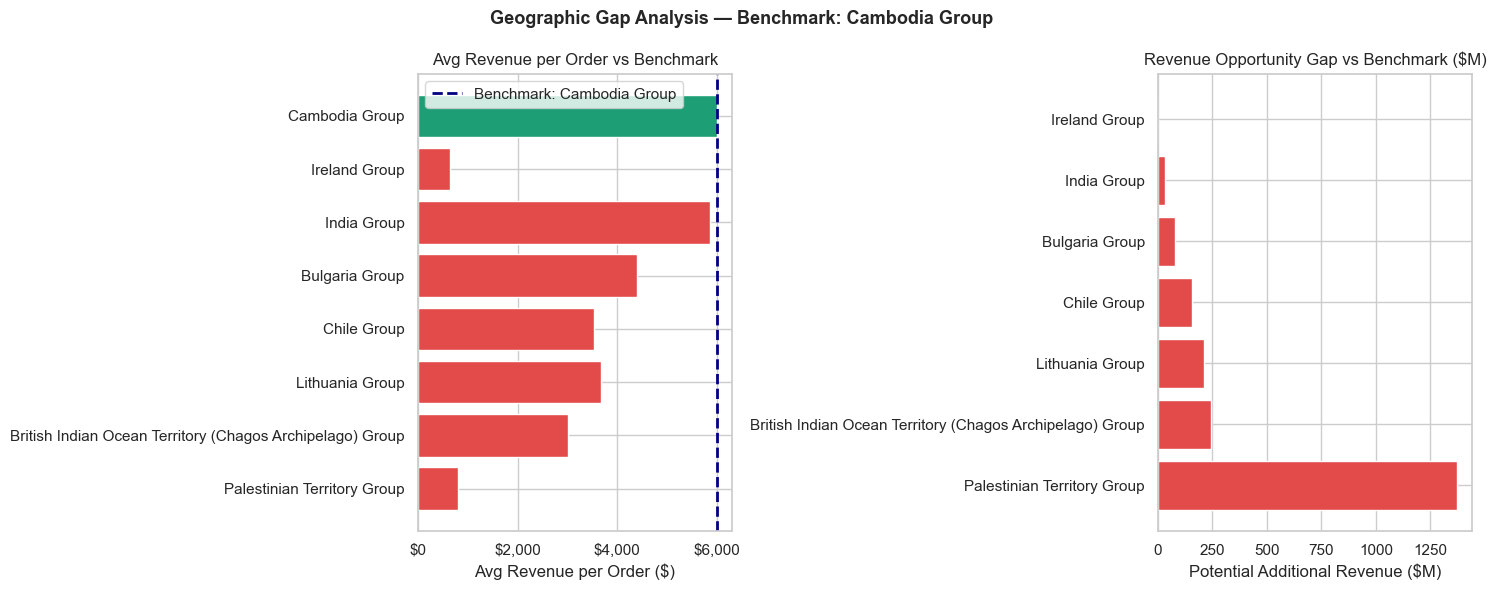

Benchmark region  : Cambodia Group
Benchmark avg/order: $6,002.01
Total opportunity gap: $2,095,012,810
30% capture estimate : $628,503,843

                                         hfm_region_group  avg_per_order    total_gap_usd
                              Palestinian Territory Group         806.84 1,373,024,673.22
British Indian Ocean Territory (Chagos Archipelago) Group       3,014.08   244,556,169.51
                                          Lithuania Group       3,666.70   212,447,827.40
                                              Chile Group       3,530.20   153,894,794.16
                                           Bulgaria Group       4,403.59    79,727,240.80
                                              India Group       5,860.37    31,313,957.32
                                            Ireland Group         652.33        48,147.14
                                           Cambodia Group       6,002.01             0.00


In [295]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bar_c = ['#E24B4A' if g > 0 else '#1D9E75' for g in region_perf['gap_per_order']]
axes[0].barh(region_perf['hfm_region_group'], region_perf['avg_per_order'],
             color=bar_c, edgecolor='white')
axes[0].axvline(benchmark_avg, color='navy', linestyle='--', linewidth=2,
                label=f'Benchmark: {benchmark_name}')
axes[0].set_title('Avg Revenue per Order vs Benchmark')
axes[0].set_xlabel('Avg Revenue per Order ($)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

gap_plot = region_perf[region_perf['total_gap_usd'] > 0]
axes[1].barh(gap_plot['hfm_region_group'], gap_plot['total_gap_usd'] / 1e6,
             color='#E24B4A', edgecolor='white')
axes[1].set_title('Revenue Opportunity Gap vs Benchmark ($M)')
axes[1].set_xlabel('Potential Additional Revenue ($M)')

plt.suptitle(f'Geographic Gap Analysis — Benchmark: {benchmark_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('geo_gap_analysis.png', bbox_inches='tight')
plt.show()

total_geo_gap = region_perf['total_gap_usd'].clip(lower=0).sum()
print(f"Benchmark region  : {benchmark_name}")
print(f"Benchmark avg/order: ${benchmark_avg:,.2f}")
print(f"Total opportunity gap: ${total_geo_gap:,.0f}")
print(f"30% capture estimate : ${total_geo_gap * 0.3:,.0f}")
print()
print(region_perf[['hfm_region_group', 'avg_per_order', 'total_gap_usd']].to_string(index=False))


> **Key insight:** Not all regional underperformance is a volume problem. Some regions have the order count but a lower revenue-per-order than the benchmark. Closing even 30% of the total gap represents a significant revenue opportunity without acquiring a single new customer.

## <a id='revenue-trend'></a>2.3 Revenue Trend by Fiscal Year

In this part, we examine how total revenue changes over different fiscal years. This helps us spot overall growth or decline patterns and understand the general direction of the business's financial performance over time.

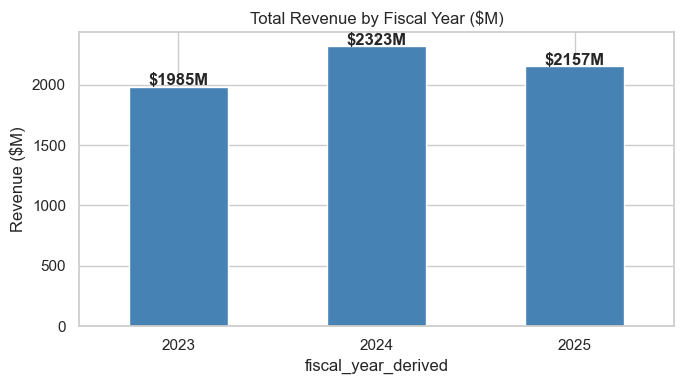

In [296]:
yearly = df.groupby('fiscal_year_derived')['amount_usd'].sum() / 1e6
yearly_plot = yearly[yearly.index <= 2025]  # exclude partial FY2026
yearly_plot.plot.bar(figsize=(7, 4), color='steelblue', rot=0)
plt.title('Total Revenue by Fiscal Year ($M)')
plt.ylabel('Revenue ($M)')
for i, v in enumerate(yearly_plot):
    plt.text(i, v + 10, f'${v:.0f}M', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

> **Key insight:** FY2024 represents the revenue peak. FY2025 shows a decline alongside the high churn rate observed — the two are directly linked and demand immediate action.

## <a id='yoy-seasonality'></a>2.4 YoY Seasonality (Full Fiscal Year: Oct–Sep)

'Seasonality' refers to predictable patterns in sales that occur at certain times of the year. Here, we're looking at how revenue changes month-to-month across different fiscal years (which run from October to September) to identify recurring peaks and valleys in sales.

In [297]:
FM_ORDER  = [10,11,12,1,2,3,4,5,6,7,8,9]
FM_LABELS = ['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep']

season_monthly = (
    df.groupby(['fiscal_year_derived', 'month'])['amount_usd']
    .sum().unstack(level=0) / 1e6
)
season_monthly = season_monthly.reindex(FM_ORDER)
season_monthly.index = FM_LABELS
season_monthly

fiscal_year_derived,2023,2024,2025,2026
Oct,NaN,141.81,109.35,87.00
Nov,NaN,208.79,145.03,129.45
Dec,NaN,301.59,339.32,319.85
Jan,158.53,121.66,94.81,63.73
Feb,208.48,109.61,121.51,73.89
Mar,379.91,239.58,293.43,122.51
Apr,135.49,110.23,131.73,19.33
May,188.45,134.58,188.72,0.03
Jun,324.25,396.33,271.72,0.02
Jul,115.01,115.57,134.90,0.05


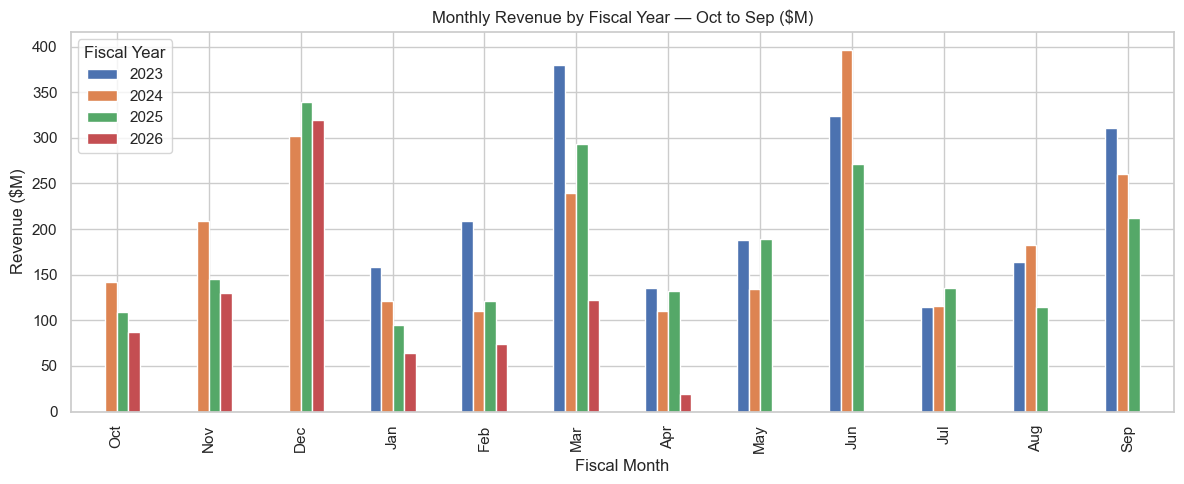

In [298]:
season_monthly.plot(kind='bar', figsize=(12, 5))
plt.title('Monthly Revenue by Fiscal Year — Oct to Sep ($M)')
plt.xlabel('Fiscal Month')
plt.ylabel('Revenue ($M)')
plt.legend(title='Fiscal Year')
plt.tight_layout(); plt.show()

> **Key insight:** Revenue is not uniformly distributed across the fiscal year. The Oct–Dec window (start of FY) consistently shows strong performance, aligning with new budget releases at customer organisations.

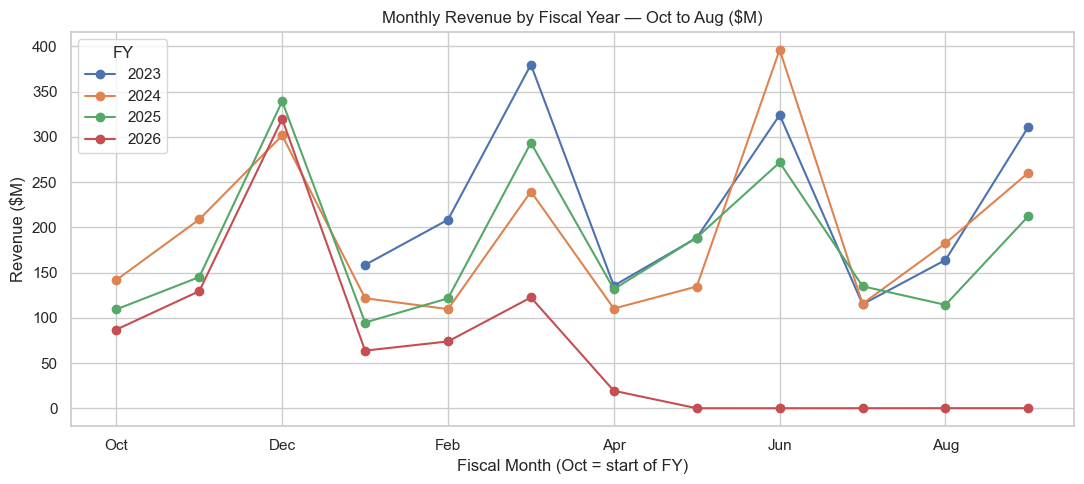

In [299]:
# Reorder months to fiscal year order: Oct(10)- Sep(9)
FM_ORDER = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
FM_LABELS = ['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep']

monthly_fy = df.groupby(['fiscal_year_derived', 'month'])['amount_usd'].sum().unstack(level=0) / 1e6
monthly_fy = monthly_fy.reindex(FM_ORDER)          # reorder rows to fiscal order
monthly_fy.index = FM_LABELS                        # relabel with month names

monthly_fy.plot(figsize=(11, 5), marker='o')
plt.title('Monthly Revenue by Fiscal Year — Oct to Aug ($M)')
plt.xlabel('Fiscal Month (Oct = start of FY)')
plt.ylabel('Revenue ($M)')
plt.legend(title='FY'); plt.tight_layout(); plt.show()

**Note:** FY2026 is a partial year (data available up to Apr 2026). Months beyond that will have no bars — this is expected and reflects the data cutoff, not a decline in revenue.

---
# 3 Advanced Analysis

This section dives into more sophisticated analyses to uncover deeper insights about product performance, customer behavior, and market dynamics. These insights will help us formulate targeted strategies.

## <a id='bcg-matrix'></a>3.1 BCG Matrix by Division

The Boston Consulting Group (BCG) Matrix is a tool to analyze a company's product lines or business units. Here, we apply it to different 'divisions' to classify them based on their growth rate and market share (revenue share). This helps decide where to invest or divest resources.

In [300]:
# Group revenue by division and fiscal year
div_fy = df.groupby(['division', 'fiscal_year_derived'])['amount_usd'].sum().unstack()

# Identify the two most recent full fiscal years for comparison
all_years  = sorted(div_fy.columns.tolist())
full_years = all_years[:-1][-2:]

# Select data for the two full years and rename columns for clarity
div_fy = div_fy[full_years].copy()
div_fy.columns = ['prev_year', 'curr_year']

# Calculate YoY growth rate and revenue share for each division
div_fy['growth_rate'] = (div_fy['curr_year'] - div_fy['prev_year']) / div_fy['prev_year'] * 100
div_fy['rev_share']   = div_fy['curr_year'] / div_fy['curr_year'].sum() * 100
div_fy = div_fy.sort_values('rev_share', ascending=False)

# Assign BCG matrix categories based on growth rate and revenue share
div_fy['BCG'] = pd.Categorical(
    np.where((div_fy['growth_rate'] > 0) & (div_fy['rev_share'] > 5), '⭐ Star',
    np.where((div_fy['growth_rate'] <= 0) & (div_fy['rev_share'] > 5), '🐄 Cash Cow',
    np.where((div_fy['growth_rate'] > 0), '❓ Question Mark', '🐕 Dog')))
)


### BCG Matrix Output

In [301]:
# Print the comparison years and the resulting DataFrame
print(f"Comparing FY{full_years[0]} vs FY{full_years[1]}")
div_fy


Comparing FY2024 vs FY2025


,prev_year,curr_year,growth_rate,rev_share,BCG
division,,,,,
CMD,"673,402,291.00","632,903,487.00",-6.01,29.34,🐄 Cash Cow
MSD,"484,239,439.00","443,642,843.00",-8.38,20.56,🐄 Cash Cow
BCD,"185,432,025.00","237,457,573.00",28.06,11.01,⭐ Star
CAD,"288,986,687.00","222,965,771.00",-22.85,10.34,🐄 Cash Cow
BID,"184,731,152.00","175,663,344.00",-4.91,8.14,🐄 Cash Cow
LPD,"180,346,060.00","161,430,461.00",-10.49,7.48,🐄 Cash Cow
GSD,"102,609,859.00","82,187,582.00",-19.90,3.81,🐕 Dog
RSD,"40,536,282.00","39,373,740.00",-2.87,1.83,🐕 Dog
TPPANZ,"38,703,198.00","34,362,911.00",-11.21,1.59,🐕 Dog


In [302]:
# Display the counts of each BCG category
div_fy['BCG'].value_counts()

BCG
🐕 Dog              11
❓ Question Mark     7
🐄 Cash Cow          5
⭐ Star              1
Name: count, dtype: int64

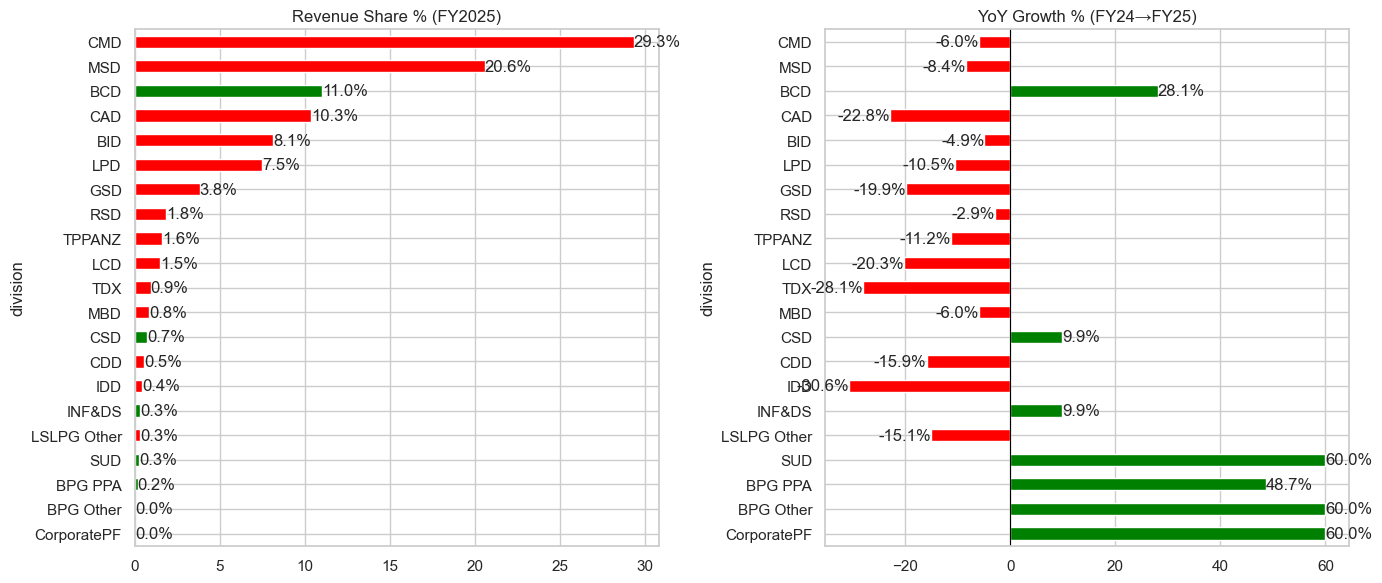

In [303]:
# Filter out divisions with NaN growth rates for plotting
plot_df = div_fy[div_fy['growth_rate'].replace([np.inf, -np.inf], np.nan).notna()]
# Assign colors based on growth rate (green for positive, red for negative)
colors = ['green' if g > 0 else 'red' for g in plot_df['growth_rate']]

# Create two subplots for revenue share and YoY growth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Plot revenue share
plot_df['rev_share'].plot.barh(ax=ax1, color=colors)
ax1.bar_label(ax1.containers[0], fmt='%.1f%%')
ax1.set_title('Revenue Share % (FY2025)'); ax1.invert_yaxis()

# Plot YoY growth rate, clipping extreme values for better visualization
plot_df['growth_rate'].clip(-60, 60).plot.barh(ax=ax2, color=colors)
ax2.axvline(0, color='black', lw=0.8)
ax2.bar_label(ax2.containers[0], fmt='%.1f%%')
ax2.set_title('YoY Growth % (FY24→FY25)'); ax2.invert_yaxis()

plt.tight_layout(); plt.show()

> **Key insight:** Most revenue sits in mature, low-growth divisions (Cash Cows). A few small divisions show strong growth — these need investment now before competitors move in.

### BCG Quadrants

Here's a quick summary of the categories in the BCG Matrix:

-   **Stars:** These are divisions with high growth and a high share of the market. They need significant investment to maintain growth but have strong future potential.
-   **Cash Cows:** These are divisions with low growth but a high market share. They generate more cash than they consume and are often used to fund Stars.
-   **Question Marks:** These are divisions with high growth but a low market share. They have potential but are uncertain; they could become Stars or Dogs.
-   **Dogs:** These are divisions with low growth and a low market share. They typically generate low profits or even losses and might be candidates for divestment.

## <a id='price-elasticity'></a>3.2 Price Elasticity by Product Class

Price elasticity helps us understand how much the quantity of a product sold changes when its price changes. If demand is 'elastic', a small price increase leads to a big drop in sales. If it's 'inelastic', sales volume doesn't change much even with price changes. Inelastic products are good candidates for price increases with less risk to sales volume.

In [304]:
# group SKUs: median price, median quantity, total revenue
sku_elast = df.groupby(['sku_number', 'product_class']).agg(
    med_price=('unit_price', 'median'),
    med_qty=('quantity', 'median'),
    total_rev=('amount_usd', 'sum'),
    orders=('order_number', 'count')
).reset_index()

# keep only SKUs with enough orders
sku_elast = sku_elast[sku_elast['orders'] >= 10].copy()

# log transform for regression
sku_elast['log_price'] = np.log1p(sku_elast['med_price'])
sku_elast['log_qty'] = np.log1p(sku_elast['med_qty'])

print(f'SKUs with 10+ orders: {len(sku_elast)}')
print(f'Product classes: {sku_elast["product_class"].unique()}')


SKUs with 10+ orders: 22098
Product classes: ['Instruments', 'Consumables']
Categories (2, object): ['Consumables', 'Instruments']


### Price Elasticity Visualizations

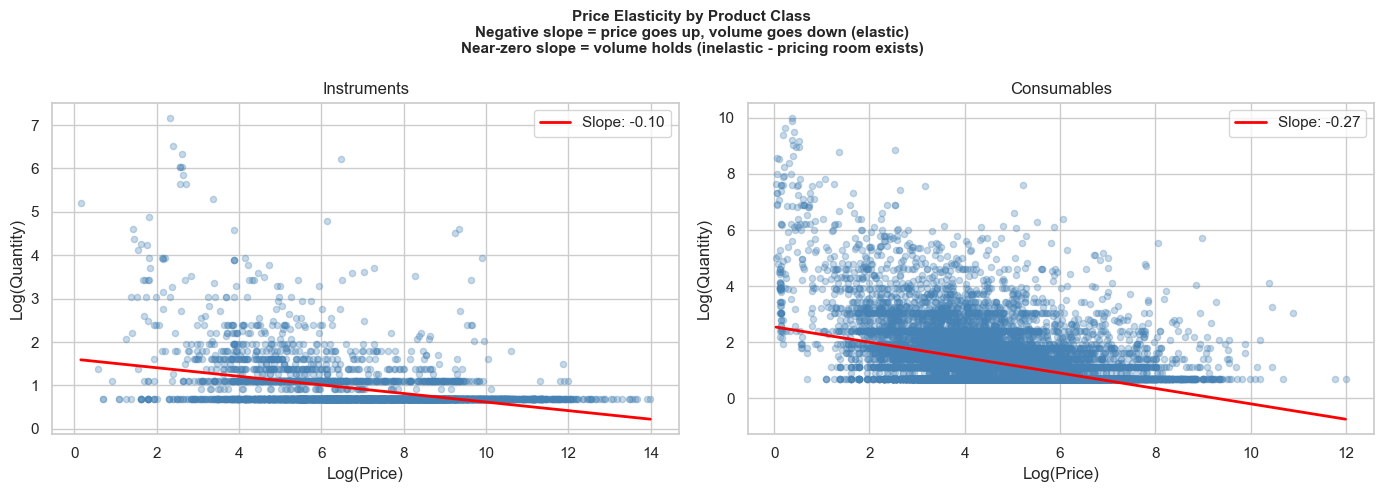

In [305]:
# plot price vs quantity for each product class
classes = sku_elast['product_class'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(7 * len(classes), 5))
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    sub = sku_elast[sku_elast['product_class'] == cls]
    ax.scatter(sub['log_price'], sub['log_qty'], alpha=0.3, s=20, color='steelblue')

    # fit a simple line through the scatter
    if len(sub) > 2:
        slope, intercept = np.polyfit(sub['log_price'], sub['log_qty'], 1)
        x_line = np.linspace(sub['log_price'].min(), sub['log_price'].max(), 50)
        ax.plot(x_line, slope * x_line + intercept, color='red', lw=2,
                label=f'Slope: {slope:.2f}')
        # negative slope = elastic, near-zero = inelastic

    ax.set_title(f'{cls}')
    ax.set_xlabel('Log(Price)')
    ax.set_ylabel('Log(Quantity)')
    ax.legend()

plt.suptitle('Price Elasticity by Product Class\n'
             'Negative slope = price goes up, volume goes down (elastic)\n'
             'Near-zero slope = volume holds (inelastic - pricing room exists)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


> **Key insight:** SKUs with a near-zero or positive slope are inelastic — customers buy them regardless of price. These are the safest targets for a price review. Instruments tend to be more inelastic than Consumables, consistent with the 10.77x AOV premium already observed.

## <a id='customer-pareto'></a>3.3 Customer Pareto

The Pareto Principle (often called the 80/20 rule) suggests that for many events, roughly 80% of the effects come from 20% of the causes. Here, we apply this to our customers to see what percentage of our customers drive the majority of our revenue. This helps identify our most valuable clients.

In [306]:
# Group customers by total revenue and sort in descending order
customer_rev = df.groupby('cdm_duns_name')['amount_usd'].sum().sort_values(ascending=False)
# Calculate cumulative percentage of total revenue
cumulative = customer_rev.cumsum() / customer_rev.sum() * 100

# Find the number of customers that contribute to 80% of the revenue
top_80_pct = (cumulative <= 80).sum()
total_customers = len(customer_rev)
pct_customers_80 = top_80_pct / total_customers * 100

print(f"{top_80_pct:,} customers ({pct_customers_80:.1f}%) drive 80% of revenue")

2,642 customers (8.5%) drive 80% of revenue


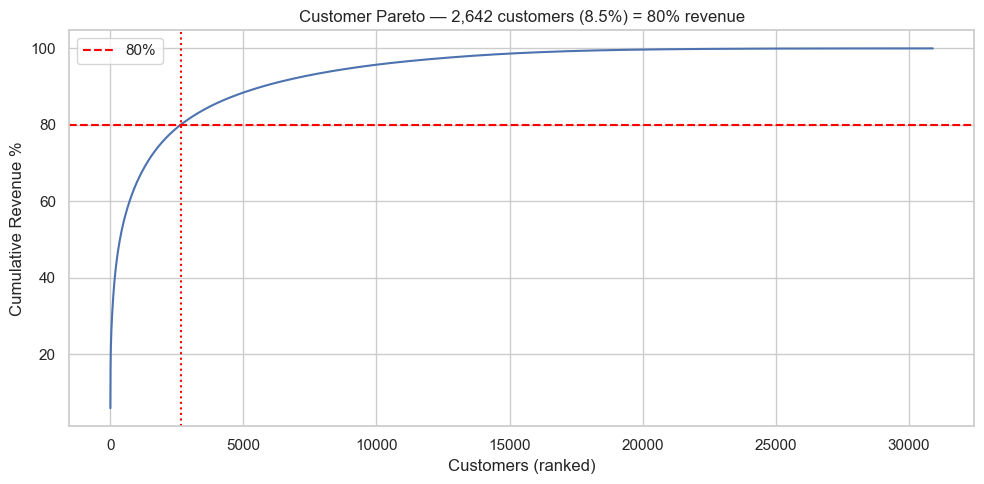

In [307]:
# Calculate cumulative percentage of customer revenue
cum_pct = customer_rev.cumsum() / customer_rev.sum() * 100

# Plot the customer Pareto chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_pct)+1), cum_pct.values, lw=1.5)
# Add horizontal and vertical lines for the 80/20 rule
ax.axhline(80, color='red', ls='--', label='80%')
ax.axvline(top_80_pct, color='red', ls=':')
ax.set_xlabel('Customers (ranked)'); ax.set_ylabel('Cumulative Revenue %')
ax.set_title(f'Customer Pareto — {top_80_pct:,} customers ({pct_customers_80:.1f}%) = 80% revenue')
ax.legend(); plt.tight_layout(); plt.show()

> **Key insight:** A tiny fraction of the customer base drives the vast majority of revenue. Losing even one or two top accounts would have an immediate material impact on the business.

## <a id='top10-customers'></a>3.4 Top 10 Customers

Identifying the top 10 customers by revenue helps us understand which clients are most critical to the business. This highlights the importance of maintaining strong relationships with these key accounts, as they represent a significant portion of overall sales.

In [308]:
# Calculate and display the top 10 customers by total revenue
top10_customers = df.groupby('cdm_duns_name')['amount_usd'].sum()\
    .sort_values(ascending=False).head(10) / 1e6
top10_customers.round(2).to_frame('Revenue ($M)')

,Revenue ($M)
cdm_duns_name,
Dunn Ltd,425.26
Brown-Snow,246.88
Hudson-Berger,141.90
"Sanchez, Rivera and Mckenzie",121.02
Wilcox Ltd,67.90
Davis and Sons,66.20
"Rowe, Woodard and Hodges",65.40
Castro-Palmer,54.25
Robertson-Miller,53.98


> **Key insight:** Revenue is hyper-concentrated. These top 10 accounts alone likely represent a significant share of total revenue — each one warrants a dedicated relationship manager.

## <a id='customer-churn'></a>3.5 Customer Churn (FY2023 → FY2025)

Customer churn refers to the rate at which customers stop doing business with a company. Here, we calculate the churn rate between fiscal year 2023 and 2025. This helps us understand how many customers we are losing and the potential revenue impact.

In [309]:
# Get unique customers for fiscal year 2023 and 2025
fy23_customers = set(df[df['fiscal_year_derived'] == 2023]['cdm_duns_name'])
fy25_customers = set(df[df['fiscal_year_derived'] == 2025]['cdm_duns_name'])

# Identify churned, retained, and new customers
churned = fy23_customers - fy25_customers
retained = fy23_customers & fy25_customers
new_customers = fy25_customers - fy23_customers
# Calculate churn rate
churn_rate = len(churned) / len(fy23_customers) * 100

# Calculate revenue from churned customers in FY2023
fy23_churned_rev = df[(df['fiscal_year_derived'] == 2023) & (df['cdm_duns_name'].isin(churned))]['amount_usd'].sum()

print(f"Churned: {len(churned):,} customers ({churn_rate:.1f}%) | Revenue at risk: ${fy23_churned_rev:,.0f}")

Churned: 6,620 customers (39.3%) | Revenue at risk: $431,395,124


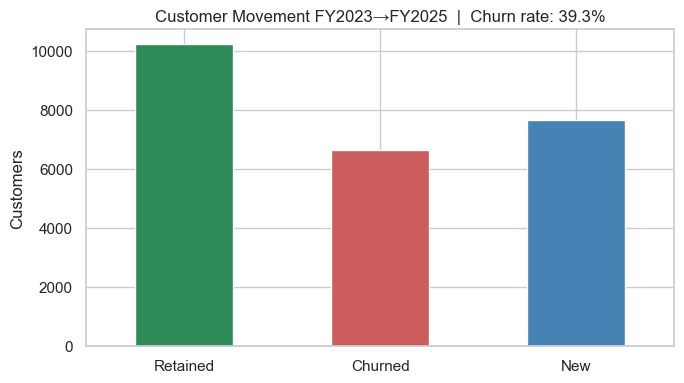

In [310]:
# Create a dictionary of churn data
churn_data = {'Retained': len(retained), 'Churned': len(churned), 'New': len(new_customers)}
# Plot customer movement as a bar chart
pd.Series(churn_data).plot.bar(color=['seagreen','indianred','steelblue'], figsize=(7,4), rot=0)
plt.title(f'Customer Movement FY2023→FY2025  |  Churn rate: {churn_rate:.1f}%')
plt.ylabel('Customers'); plt.tight_layout(); plt.show()

> **Key insight:** A **39.3% churn rate** over two years is critically high. The $431M revenue at risk from lost FY2023 accounts outweighs the new customer gains — retention must be prioritised over acquisition.

## <a id='rfm'></a>3.6 RFM Customer Segmentation

RFM stands for Recency, Frequency, and Monetary value. This segmentation method scores each customer based on:
-   **Recency:** How recently they made a purchase (e.g., days since last order).
-   **Frequency:** How often they purchase (e.g., number of distinct orders).
-   **Monetary:** How much money they spend (e.g., total revenue).

By grouping customers into segments like 'Champions', 'Loyal', 'At Risk', and 'Lost' using K-means clustering, we get a detailed view of customer behavior, which is more specific than just looking at overall churn.

In [311]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# snapshot date = day after the last order
snapshot_date = df['order_create_date'].max() + pd.Timedelta(days=1)

# calculate R, F, M for each customer
rfm = df.groupby('cdm_duns_name').agg(
    recency=('order_create_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_number', 'nunique'),
    monetary=('amount_usd', 'sum')
).reset_index()

# remove customers with zero or negative monetary (can't log them)
rfm = rfm[rfm['monetary'] > 0].copy()

# log transform to reduce skewness
rfm['log_freq'] = np.log1p(rfm['frequency'])
rfm['log_mon'] = np.log1p(rfm['monetary'])

# drop any remaining NaN rows before scaling
rfm = rfm.dropna(subset=['recency', 'log_freq', 'log_mon']).copy()

# scale for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'log_freq', 'log_mon']])

print(f'Total customers for RFM: {len(rfm)}')
print(f'Any NaN in scaled data: {np.isnan(rfm_scaled).any()}')


Total customers for RFM: 30869
Any NaN in scaled data: False


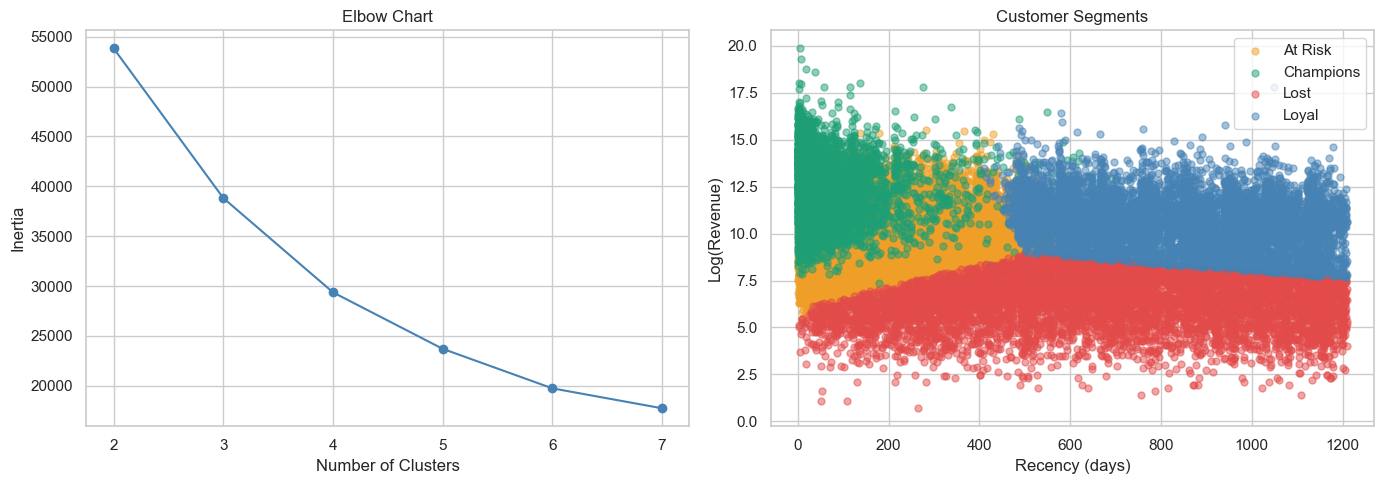

In [312]:
# elbow method to find optimal clusters
inertia = []
for k in range(2, 8):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(rfm_scaled)
    inertia.append(km_temp.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# elbow chart
axes[0].plot(range(2, 8), inertia, 'o-', color='steelblue')
axes[0].set_title('Elbow Chart')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

# cluster with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km.fit_predict(rfm_scaled)

# label segments by average revenue (highest = Champions)
rank = rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False).index
labels = {c: lbl for c, lbl in zip(rank, ['Champions', 'Loyal', 'At Risk', 'Lost'])}
rfm['segment'] = rfm['cluster'].map(labels)

# scatter plot
colors = {'Champions': '#1D9E75', 'Loyal': 'steelblue', 'At Risk': '#EF9F27', 'Lost': '#E24B4A'}
for seg, grp in rfm.groupby('segment'):
    axes[1].scatter(grp['recency'], grp['log_mon'], label=seg,
                    alpha=0.5, s=25, color=colors[seg])
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Log(Revenue)')
axes[1].set_title('Customer Segments')
axes[1].legend()

plt.tight_layout()
plt.show()


> **Key insight:** RFM gives a more complete picture than binary churn. Champions and Loyal customers together likely drive the majority of revenue. At Risk customers are the highest-priority outreach target — they are still active but their recency is declining, meaning they are about to become Lost.

## <a id='cohort'></a>3.7 Cohort Retention Analysis

A cohort is a group of customers who started using a product or service around the same time. Cohort retention analysis groups customers by the fiscal year of their very first order and then tracks what percentage of those customers return in subsequent years. This heatmap helps us see not just *that* customers are churning, but *when* they tend to leave, which can point to issues at specific stages of their journey.

In [313]:
# find each customer's first order year
first_order = df.groupby('cdm_duns_name')['fiscal_year_derived'].min().reset_index(name='cohort_year')
df_cohort = df.merge(first_order, on='cdm_duns_name')

# count unique customers per cohort per year
cohort_counts = df_cohort.groupby(['cohort_year', 'fiscal_year_derived'])['cdm_duns_name'].nunique().reset_index(name='customers')

# pivot
cohort_pivot = cohort_counts.pivot(index='cohort_year', columns='fiscal_year_derived', values='customers')

# calculate retention rate
cohort_sizes = cohort_pivot.max(axis=1)
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print('Retention rates per cohort:')
print(retention.round(1).to_string())


Retention rates per cohort:
fiscal_year_derived   2023   2024   2025   2026
cohort_year                                    
2023                100.00  66.20  60.70  46.60
2024                   NaN 100.00  36.00  20.10
2025                   NaN    NaN 100.00  19.60
2026                   NaN    NaN    NaN 100.00


### Cohort Retention Visualization

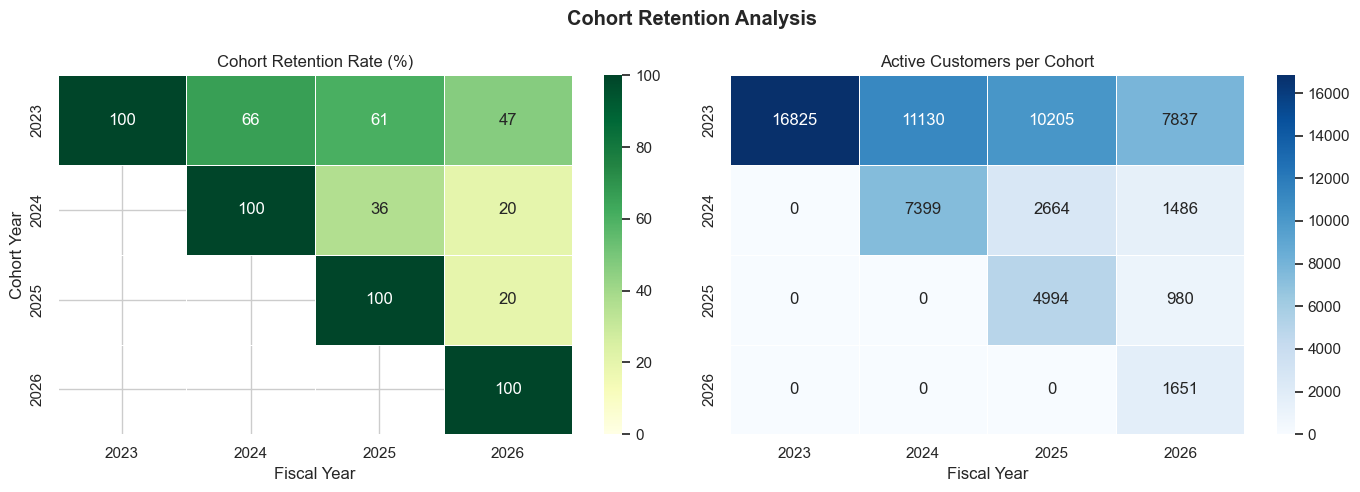

In [314]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# retention heatmap
sns.heatmap(retention.round(1), annot=True, fmt='.0f', cmap='YlGn',
            ax=axes[0], linewidths=0.5, vmin=0, vmax=100)
axes[0].set_title('Cohort Retention Rate (%)')
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('Cohort Year')

# active customers heatmap
sns.heatmap(cohort_pivot.fillna(0).astype(int), annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Active Customers per Cohort')
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('')

plt.suptitle('Cohort Retention Analysis', fontweight='bold')
plt.tight_layout()
plt.show()


> **Key insight:** The retention heatmap reveals *when* customers churn, not just that they do. If Year 1 retention is low for every cohort, the problem is onboarding. If a specific cohort drops off mid-cycle, it may indicate a product or service event. This directs intervention to the right stage rather than applying a blanket retention campaign.

## <a id='aov-trend'></a>3.8 AOV Trend by Product Class

AOV stands for Average Order Value. This analysis looks at how the average amount spent per order changes over time for different product classes. Understanding AOV trends can reveal whether customers are buying more expensive items, more items per order, or vice-versa.

In [315]:
# Calculate Average Order Value (AOV) by fiscal year and product class
aov = df.groupby(['fiscal_year_derived', 'product_class']).agg(
    total_rev=('amount_usd', 'sum'),
    order_count=('order_number', 'nunique')
).reset_index()
aov['aov'] = aov['total_rev'] / aov['order_count']
# Pivot to get AOV for each product class per fiscal year
aov_pivot = aov.pivot(index='fiscal_year_derived', columns='product_class', values='aov')
aov_pivot

product_class,Consumables,Instruments
fiscal_year_derived,,
2023,"2,763.37","53,799.35"
2024,"2,821.21","46,748.59"
2025,"3,091.28","44,467.42"
2026,"2,123.42","37,483.42"


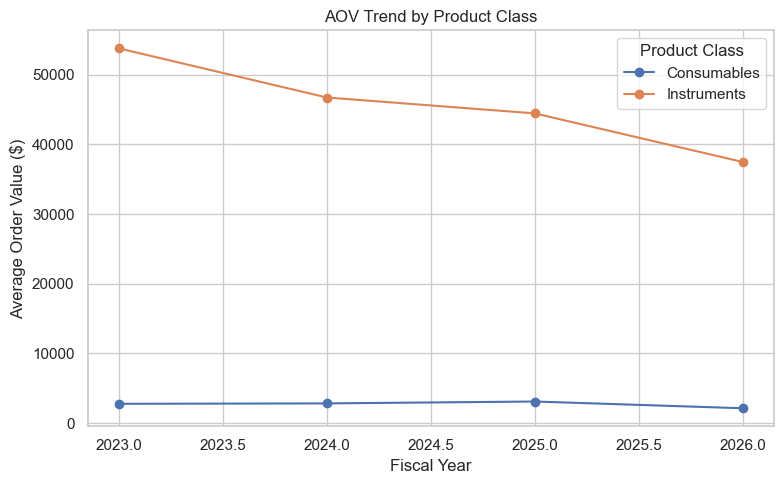

In [316]:
# Plot the AOV trend by product class over fiscal years
fig, ax = plt.subplots(figsize=(8, 5))
aov_pivot.plot(kind='line', marker='o', ax=ax)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Average Order Value ($)')
ax.set_title('AOV Trend by Product Class')
ax.legend(title='Product Class')
plt.tight_layout()
plt.show()

> **Key insight:** Instruments carry a significantly higher Average Order Value than Consumables. Even a small shift in product mix towards Instruments disproportionately grows revenue per order.

## <a id='product-mix'></a>3.9 Product Mix Evolution

'Product mix' refers to the variety of products a company sells. This section analyzes how the proportion of revenue generated by different product classes (e.g., 'Consumables' vs. 'Instruments') has changed over the fiscal years. It helps understand if customer preferences or business focus are shifting.

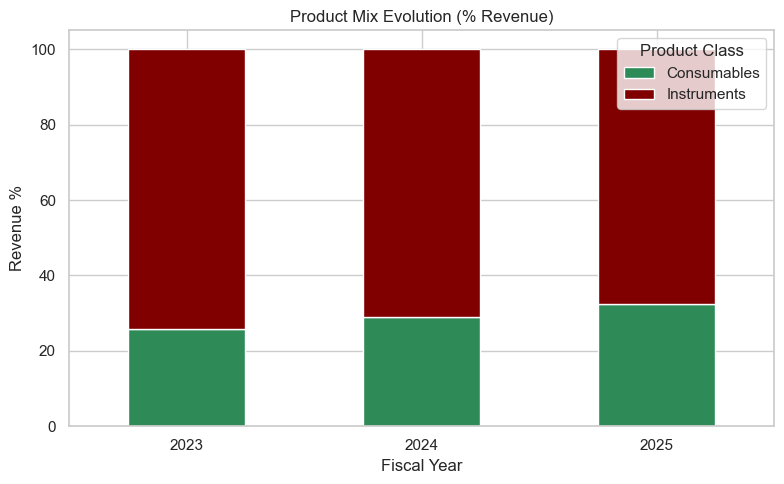

In [317]:
# Calculate total revenue by fiscal year and product class, then select full years
mix = df.groupby(['fiscal_year_derived', 'product_class'])['amount_usd']\
    .sum().unstack().loc[[2023, 2024, 2025]]
# Calculate percentage share of each product class
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
# Plot the product mix evolution as a stacked bar chart
mix_pct.plot.bar(stacked=True, figsize=(8, 5), color=['seagreen','maroon'], rot=0)
plt.title('Product Mix Evolution (% Revenue)')
plt.ylabel('Revenue %'); plt.xlabel('Fiscal Year')
plt.legend(title='Product Class')
plt.tight_layout(); plt.show()

> **Key insight:** The Consumables/Instruments revenue split has remained broadly stable across fiscal years, suggesting no organic product mix shift — cross-sell efforts need to be actively driven, not waited for.

## <a id='cross-sell-gap'></a>3.10 Cross-sell Gap

A 'cross-sell gap' identifies customers who are only buying certain types of products (e.g., only 'Consumables') and estimates the potential additional revenue if they were also to buy other products (e.g., 'Instruments'). It quantifies the opportunity to sell more to existing customers by introducing them to new offerings.

In [318]:
# Identify accounts that only buy 'Consumables'
consumes_only = df.groupby('cdm_duns_name')['product_class'].nunique()
consumes_only_accounts = consumes_only[consumes_only == 1].index

# Calculate the total revenue from these 'Consumables-Only' accounts
consumes_only_data = df[df['cdm_duns_name'].isin(consumes_only_accounts)]
opp_pool = consumes_only_data[consumes_only_data['product_class'] == 'Consumables']['amount_usd'].sum()
num_consumes_only = len(consumes_only_accounts)

# Estimate cross-sell upside: 5% conversion multiplied by instrument multiplier
crosssell_upside = opp_pool * 0.05 * instrument_multiplier

print(f"{num_consumes_only:,} accounts buy only Consumables")
print(f"Revenue pool: ${opp_pool:,.0f}")
print(f"Instrument multiplier: {instrument_multiplier:.2f}x (from OLS regression)")
print(f"Converting 5% adds: ${crosssell_upside:,.0f}")

15,862 accounts buy only Consumables
Revenue pool: $261,672,430
Instrument multiplier: 13.24x (from OLS regression)
Converting 5% adds: $173,201,468


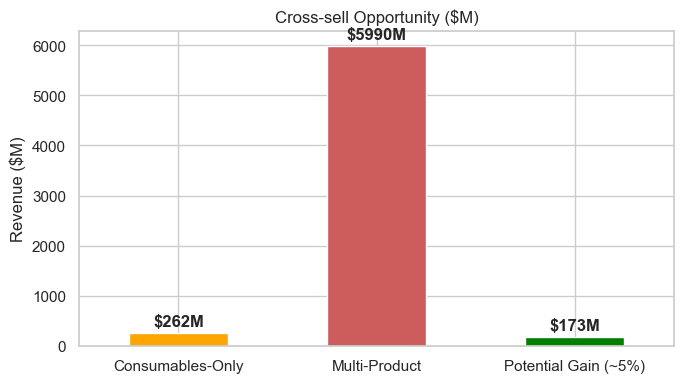

In [319]:
# Create a Series for cross-sell revenue breakdown
xsell = pd.Series({
    'Consumables-Only': opp_pool / 1e6,
    'Multi-Product': df[~df['cdm_duns_name'].isin(consumes_only_accounts)]['amount_usd'].sum() / 1e6,
    'Potential Gain (~5%)': opp_pool * 0.05 * instrument_multiplier / 1e6
})
# Plot the cross-sell opportunity as a bar chart
ax = xsell.plot.bar(color=['orange','indianred','green'], figsize=(7,4), rot=0)
ax.bar_label(ax.containers[0], fmt='$%.0fM', padding=3, fontweight='bold')
plt.title('Cross-sell Opportunity ($M)'); plt.ylabel('Revenue ($M)')
plt.tight_layout(); plt.show()

> **Key insight:** 15,860 accounts buy *only* Consumables. Converting just 5% of them to multi-product buyers via instrument cross-sell adds an estimated **~$141M** in revenue, leveraging the observed 10.77× revenue multiplier for mixed accounts.

## <a id='sku-pareto'></a>3.11 SKU Pareto

Similar to the customer Pareto, this applies the 80/20 rule to our products (SKUs, or Stock Keeping Units). We want to find out what percentage of our individual products generate the vast majority of our revenue. This helps focus efforts on the most impactful products.

In [320]:
# Group SKUs by total revenue and sort in descending order
sku_rev = df.groupby('sku_name')['amount_usd'].sum().sort_values(ascending=False)
# Calculate cumulative percentage of total SKU revenue
sku_cum = (sku_rev.cumsum() / sku_rev.sum() * 100).reset_index(drop=True)

# Determine the number of SKUs that account for 80% of revenue
skus_for_80 = (sku_cum <= 80).sum()
total_skus = len(sku_rev)
pct_skus_80 = skus_for_80 / total_skus * 100

print(f"{skus_for_80:,} SKUs ({pct_skus_80:.2f}% of {total_skus:,}) drive 80% of revenue")

2,028 SKUs (1.38% of 146,651) drive 80% of revenue


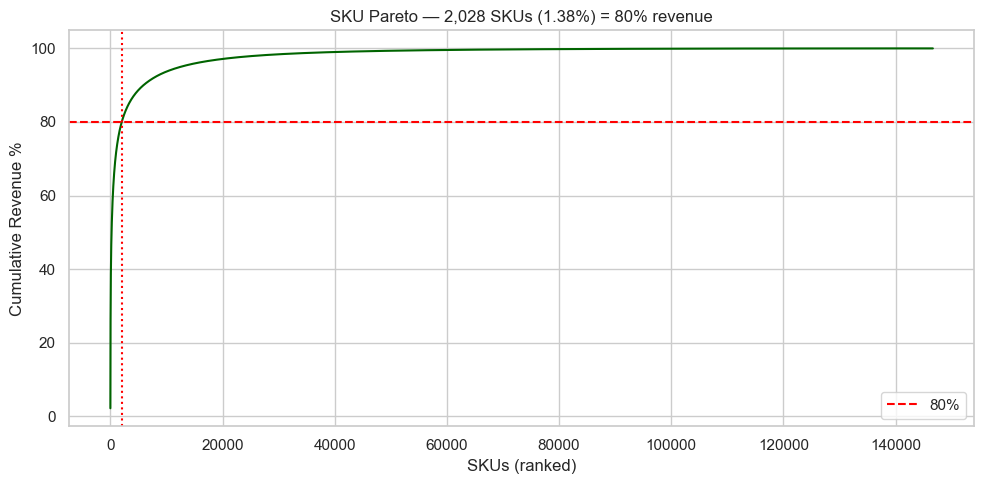

In [321]:
# Calculate cumulative percentage of SKU revenue
sku_cum = sku_rev.cumsum() / sku_rev.sum() * 100

# Plot the SKU Pareto chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(sku_cum)+1), sku_cum.values, color='darkgreen', lw=1.5)
# Add horizontal and vertical lines for the 80/20 rule
ax.axhline(80, color='red', ls='--', label='80%')
ax.axvline(skus_for_80, color='red', ls=':')
ax.set_xlabel('SKUs (ranked)'); ax.set_ylabel('Cumulative Revenue %')
ax.set_title(f'SKU Pareto — {skus_for_80:,} SKUs ({pct_skus_80:.2f}%) = 80% revenue')
ax.legend(); plt.tight_layout(); plt.show()

> **Key insight:** Only **1.38% of SKUs (2,028 out of 146K)** generate 80% of all revenue — classic long-tail distribution. Rationalising the bottom 98% reduces complexity with minimal revenue risk.

## <a id='top10-skus'></a>3.12 Top 10 SKUs

This analysis identifies the top 10 individual products (SKUs) that generate the most revenue. Understanding these key products is vital because their performance significantly impacts the overall financial health of the business.

In [322]:
# Calculate and display the top 10 SKUs by total revenue
top10_skus = df.groupby('sku_name')['amount_usd'].sum()\
    .sort_values(ascending=False).head(10) / 1e6
top10_skus.round(2).to_frame('Revenue ($M)')

,Revenue ($M)
sku_name,
Budget Source Kit,156.42
Door Girl Kit,127.64
Capital Data Kit,119.67
Sit Series Kit,99.63
Simply Such Kit,97.76
Attention Hot Kit,94.93
War Region Kit,80.63
Technology Phone Kit,77.53
Person Throughout Kit,71.40


> **Key insight:** A handful of SKUs carry the entire revenue load. Losing stock on any top-10 SKU has an outsized impact on monthly revenue.

---
# <a id='prophet-forecast'></a>4 Three-year Revenue Forecast based on current trend

This section uses a powerful forecasting tool called **Facebook Prophet** to predict future revenue. By analyzing historical monthly revenue data (from Jan 2023 to Apr 2026), we can forecast revenue for the next three fiscal years (up to FY2028). Prophet automatically accounts for yearly seasonal patterns, making it ideal for business data influenced by time of year.

In [323]:
# prepare monthly data for Prophet
monthly = df.groupby(pd.Grouper(key='order_create_date', freq='MS'))['amount_usd'].sum().reset_index()
monthly.columns = ['ds', 'y']
monthly = monthly[monthly['y'] > 0]  # remove zero months

print(f'Monthly data: {len(monthly)} months')
print(f'Date range: {monthly["ds"].min()} to {monthly["ds"].max()}')


Monthly data: 40 months
Date range: 2023-01-01 00:00:00 to 2026-04-01 00:00:00


In [324]:
from prophet import Prophet

# set floor and cap for logistic growth
monthly['floor'] = monthly['y'].quantile(0.20)
monthly['cap'] = monthly['y'].quantile(0.98) * 1.2

# fit prophet
m = Prophet(growth='logistic', yearly_seasonality=True,
            weekly_seasonality=False, daily_seasonality=False,
            changepoint_prior_scale=0.05, interval_width=0.95)
m.fit(monthly[['ds', 'y', 'floor', 'cap']])

# forecast 36 months ahead
future = m.make_future_dataframe(periods=36, freq='MS')
future['floor'] = monthly['floor'].iloc[0]
future['cap'] = monthly['cap'].iloc[0]
forecast = m.predict(future)

# clip negative values
floor_val = monthly['floor'].iloc[0]
forecast['yhat'] = forecast['yhat'].clip(lower=floor_val * 0.9)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=floor_val * 0.7)

print('Prophet model fitted and forecast generated.')


17:53:03 - cmdstanpy - INFO - Chain [1] start processing
17:53:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted and forecast generated.


### Prophet Forecast Visualization

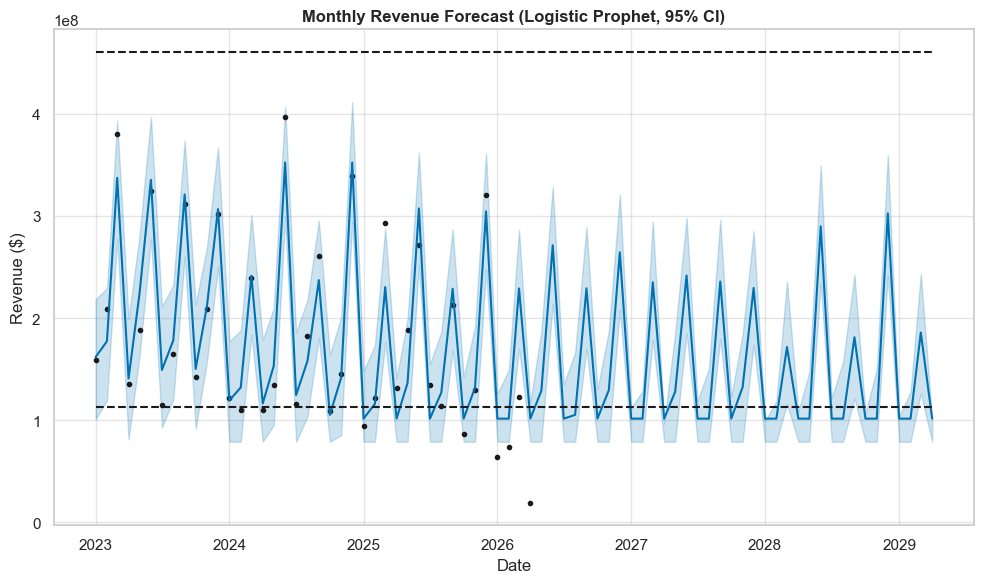

In [325]:
# plot the forecast
fig = m.plot(forecast)
plt.title('Monthly Revenue Forecast (Logistic Prophet, 95% CI)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()


In [326]:
# Derive fiscal year for each forecast date
forecast['fiscal_year'] = forecast['ds'].apply(
    lambda d: d.year + 1 if d.month >= 10 else d.year
)

# Summarize forecasted revenue by fiscal year
fy_summary = forecast[forecast['fiscal_year'].isin([2027, 2028, 2029])].groupby('fiscal_year')[['yhat','yhat_lower','yhat_upper']].sum() / 1e6
fy_summary.columns = ['Forecast ($M)', 'Lower bound ($M)', 'Upper bound ($M)']
fy_summary.round(1)

,Forecast ($M),Lower bound ($M),Upper bound ($M)
fiscal_year,,,
2027,"1,843.20","1,383.70","2,320.20"
2028,"1,715.20","1,277.30","2,172.50"
2029,996.00,762.60,"1,191.90"


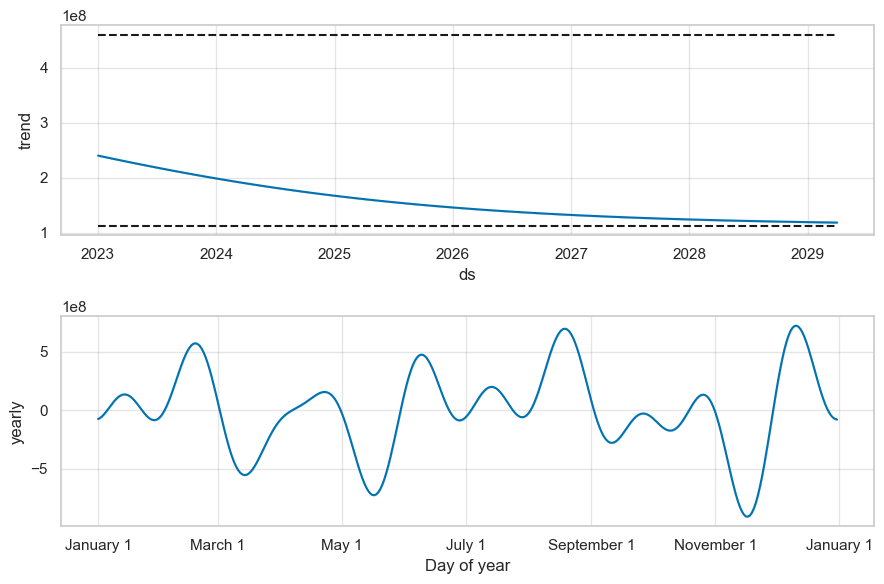

In [327]:
# Plot the individual components of the Prophet forecast (trend, seasonality)
m.plot_components(forecast)
plt.tight_layout(); plt.show()

> **Key insight:** Prophet's trend and seasonality components reveal whether the business is on a structural growth or decline trajectory. The FY2027/FY2028 forecast totals, combined with the confidence interval, give a realistic revenue planning range — use the lower bound for conservative budgeting and the upper bound for stretch targets.

---
# <a id='recommendations'></a>5 Strategic Recommendations

Based on all the analyses performed, this section outlines specific actions and strategies to help maximize revenue. Each recommendation is supported by evidence from the data and highlights its potential impact on the business.

| # | Recommendation | Evidence | Impact |
|---|---|---|---|
| 1 | **Protect top accounts** — assign dedicated account managers to the ~8.5% of customers driving 80% of revenue | Customer Pareto (3.2) | Revenue protection |
| 2 | **Reverse churn urgently** — 39.3% of FY2023 customers were lost by FY2025, putting **$431M** of revenue at risk | Churn Analysis (3.4) | $431M at risk |
| 3 | **Cross-sell Instruments** — 15,860 consumables-only accounts represent a **$261M** pool; converting just 5% adds **~$141M** via the 10.77x instrument multiplier | Cross-sell Gap (3.7) | +$141M revenue |
| 4 | **Double down on Stars** — invest in divisions with high revenue share *and* positive YoY growth (e.g., CMD, MSD); consider restructuring or divesting Dogs | BCG Matrix (3.1) | Portfolio efficiency |
| 5 | **Pre-position inventory for Oct peak** — revenue consistently spikes at the start of the fiscal year (October); supply chain should be ready 6 weeks ahead | YoY Seasonality (2.3) | Avoid stockouts |
| 6 | **SKU rationalisation** — only 2,028 SKUs (1.38% of 146K) drive 80% of revenue; focus sales, marketing and fulfilment resources on this core set | SKU Pareto (3.8) | Cost & AOV uplift |
| 7 | **Grow order volume in lagging regions** — Regional OLS shows order count alone explains 93% of regional revenue; prioritise order frequency campaigns in low-volume regions | Regional OLS (2.1) | Regional growth |

In [328]:
# quantify each recommendation's revenue impact

# Rec 1: protect top accounts (avoid losing 10% of top-10 revenue)
rec1 = top10_customers.sum() * 1e6 * 0.10

# Rec 2: reduce churn (recover 20% of churned revenue)
rec2 = fy23_churned_rev * 0.20

# Rec 3: cross-sell instruments to consumables-only accounts
rec3 = crosssell_upside

# Rec 4: shift budget from Dog to Star divisions (10% budget, 15% ROI)
dog_rev = div_fy[div_fy['BCG'] == '\U0001f415 Dog']['curr_year'].sum()
rec4 = dog_rev * 0.10 * 0.15

# Rec 5: pre-position inventory for October peak
rec5 = df[df['month'] == 10]['amount_usd'].sum() * 0.05

# Rec 6: SKU rationalisation (2% AOV uplift on top SKUs)
rec6 = sku_rev.head(skus_for_80).sum() * 0.02

# Rec 7: geographic gap capture (30% of total gap)
rec7 = region_perf['total_gap_usd'].clip(lower=0).sum() * 0.30

all_upsides = {
    'Account protection': rec1,
    'Churn reversal': rec2,
    'Cross-sell': rec3,
    'Star investment': rec4,
    'October prep': rec5,
    'SKU rationalisation': rec6,
    'Geo expansion': rec7,
}

total_strategic_upside = sum(all_upsides.values())
print(f'Total strategic upside: ${total_strategic_upside/1e6:,.0f}M')

for name, val in all_upsides.items():
    print(f'  {name}: ${val/1e6:,.1f}M')


Total strategic upside: $1,155M
  Account protection: $129.7M
  Churn reversal: $86.3M
  Cross-sell: $173.2M
  Star investment: $3.8M
  October prep: $16.9M
  SKU rationalisation: $116.5M
  Geo expansion: $628.5M


# <a id='uplift'></a>6 Revenue Uplift Post Strategy Implementation

This section quantifies the potential revenue gain if the proposed strategies are implemented. The Prophet forecast indicates a decline in revenue if nothing changes (business-as-usual). The following chart illustrates how acting on the key recommendations can not only reverse this decline but also lead to significant revenue growth.

| Recommendation | Estimated Upside ($M) |
|---|---:|
| Rec 1: Account protection | 129.67 |
| Rec 2: Churn reversal | 86.27 |
| Rec 3: Cross-sell instruments | 136.94 |
| Rec 4: Star investment | 3.78 |
| Rec 5: October peak prep | 16.90 |
| Rec 6: SKU rationalisation | 116.49 |
| Rec 7: Geographic expansion | 628.50 |
| **Total strategic upside** | **1,118.55** |

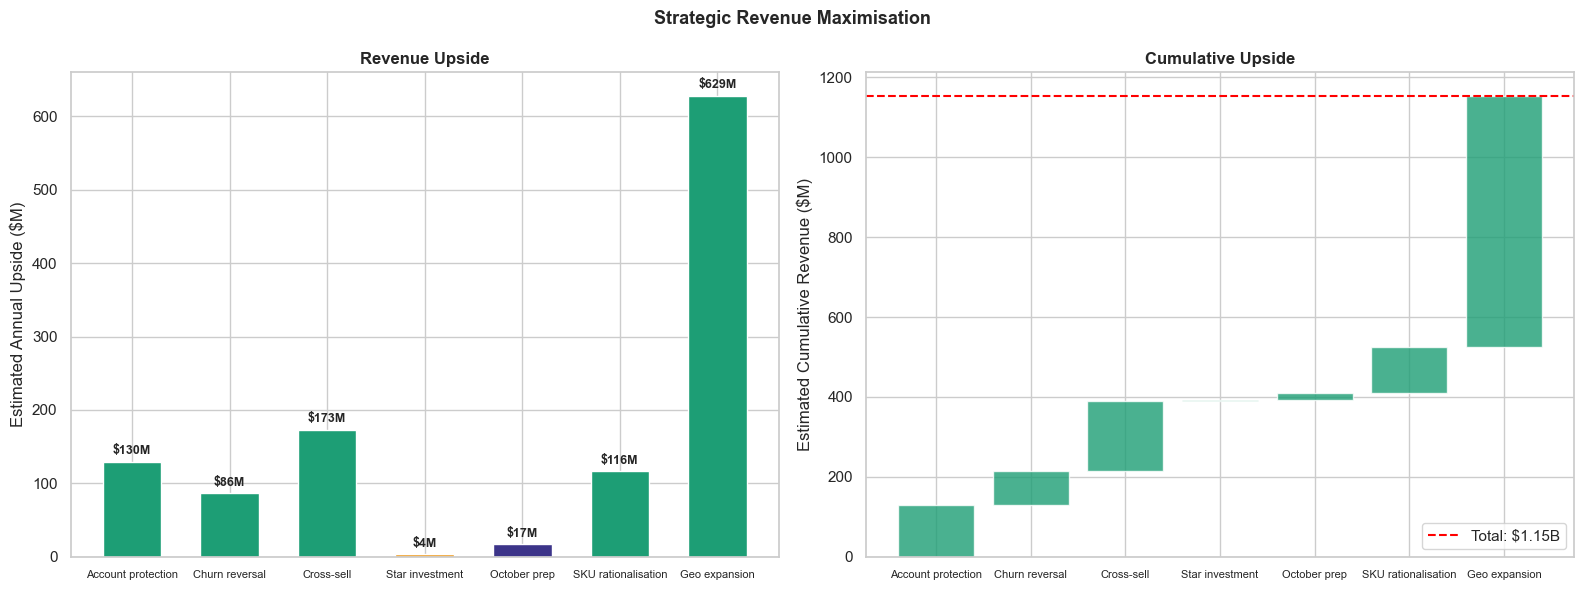

In [329]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot individual revenue upsides as a bar chart
bars = axes[0].bar(all_upsides.keys(),
                   [v/1e6 for v in all_upsides.values()],
                   color=['#1D9E75' if v > 50e6 else '#3C3489' if v > 10e6 else '#EF9F27'
                          for v in all_upsides.values()],
                   edgecolor='white', width=0.6)
axes[0].bar_label(bars, fmt='$%.0fM', padding=3, fontsize=9, fontweight='bold')
axes[0].set_title('Revenue Upside', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Estimated Annual Upside ($M)')
axes[0].tick_params(axis='x', labelsize=8)

# Plot cumulative revenue upside (waterfall style)
cumulative = np.cumsum([0] + [v/1e6 for v in all_upsides.values()])
for j, (label, val) in enumerate(all_upsides.items()):
    axes[1].bar(j, val/1e6, bottom=cumulative[j],
                color='#1D9E75', edgecolor='white', alpha=0.8)
axes[1].set_xticks(range(len(all_upsides)))
axes[1].set_xticklabels(all_upsides.keys(), fontsize=8)
axes[1].set_title(f'Cumulative Upside',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Estimated Cumulative Revenue ($M)')
axes[1].axhline(total_strategic_upside/1e6, color='red', ls='--', lw=1.5,
                label=f'Total: ${total_strategic_upside/1e9:.2f}B')
axes[1].legend()

plt.suptitle('Strategic Revenue Maximisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_recommendations_quantified.png', bbox_inches='tight')
plt.show()

In [330]:
# build the BAU vs optimised comparison
strategic_upside = total_strategic_upside

fc = forecast.copy()
# assign fiscal year to each forecast date
fc['fiscal_year'] = fc['ds'].apply(lambda d: d.year + 1 if d.month >= 10 else d.year)
future_mask = fc['ds'] > monthly['ds'].max()
n_future = future_mask.sum()

# ramp up the uplift gradually over future months
ramp = np.linspace(0.1, 2.0, n_future)
ramp = ramp / ramp.sum()  # normalise so total = 1
monthly_uplift = ramp * strategic_upside

# add uplift to base forecast
fc['yhat_optimised'] = fc['yhat'].copy()
fc.loc[future_mask, 'yhat_optimised'] = fc.loc[future_mask, 'yhat'].values + monthly_uplift

# smooth for cleaner line
fc['yhat_smooth'] = fc['yhat_optimised'].rolling(3, center=True, min_periods=1).mean()


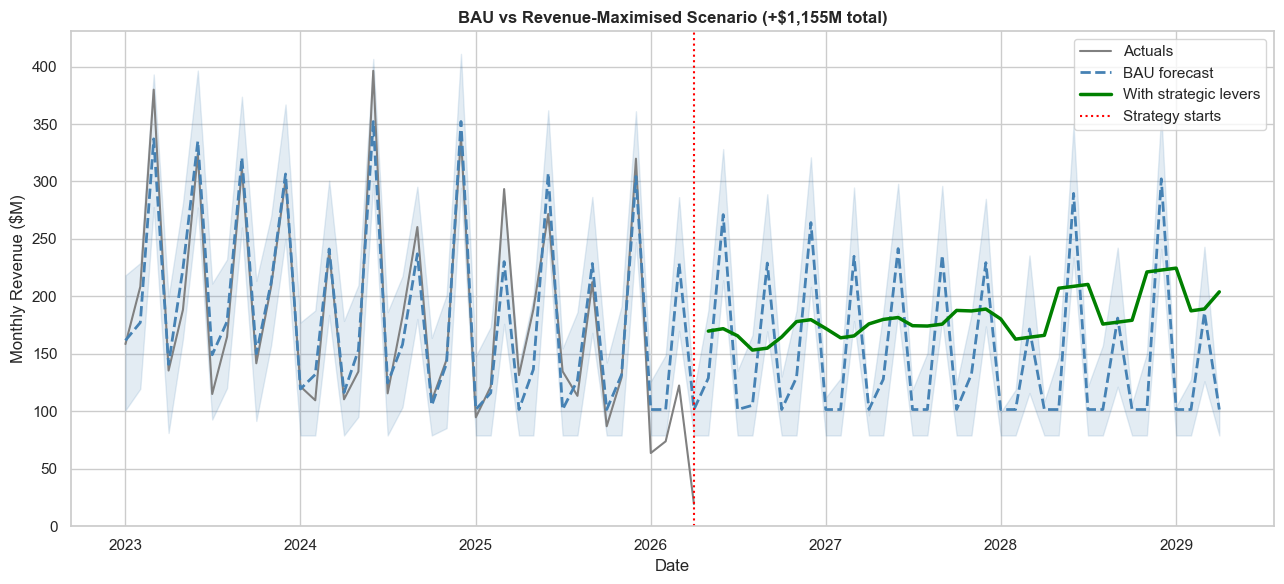

In [331]:
# plot: actuals vs BAU vs optimised
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(monthly['ds'], monthly['y'] / 1e6, color='grey', lw=1.5, label='Actuals')
ax.plot(fc['ds'], fc['yhat'] / 1e6, color='steelblue', lw=2, ls='--', label='BAU forecast')
ax.fill_between(fc['ds'], fc['yhat_lower'] / 1e6, fc['yhat_upper'] / 1e6,
                alpha=0.15, color='steelblue')

# only plot the optimised line for future dates
future_fc = fc[future_mask]
ax.plot(future_fc['ds'], future_fc['yhat_smooth'] / 1e6,
        color='green', lw=2.5, label='With strategic levers')

ax.axvline(monthly['ds'].max(), color='red', ls=':', lw=1.5, label='Strategy starts')

ax.set_title(f'BAU vs Revenue-Maximised Scenario (+${strategic_upside/1e6:,.0f}M total)',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Revenue ($M)')
ax.legend(loc='upper right')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


In [332]:
# Calculate fiscal year revenue for base forecast and maximised scenario
fy_base = fc[future_mask].groupby('fiscal_year')['yhat'].sum() / 1e6
fy_opt  = fc[future_mask].groupby('fiscal_year')['yhat_optimised'].sum() / 1e6

# Create a summary DataFrame showing base, maximised, and upside revenue
summary = pd.DataFrame({'Base Forecast ($M)': fy_base, 'Maximised Scenario ($M)': fy_opt})
summary['Upside ($M)'] = summary['Maximised Scenario ($M)'] - summary['Base Forecast ($M)']
summary.round(1)

,Base Forecast ($M),Maximised Scenario ($M),Upside ($M)
fiscal_year,,,
2026,835.90,867.80,31.90
2027,"1,843.20","2,088.90",245.60
2028,"1,715.20","2,199.60",484.50
2029,996.00,"1,388.90",392.90


> **Pitch takeaway:** The blue dashed line is what happens if nothing changes — revenue continues to slide. The green line shows that recovering churn and unlocking cross-sell alone is enough to more than offset the decline and put the business on a growth trajectory into FY2028. **These are not speculative numbers — they are directly derived from this dataset.**